In [3]:
import h5py
from pathlib import Path

src_path = Path("/home/benhua/DexSim/dexmimicgen/datasets/generated/two_arm_drawer_cleanup.hdf5")

outputs = {
    "demo_0": Path("/home/benhua/DexSim/dexmimicgen/datasets/generated/two_arm_drawer_cleanup_demo_0.hdf5"),
    "demo_1": Path("/home/benhua/DexSim/dexmimicgen/datasets/generated/two_arm_drawer_cleanup_demo_1.hdf5"),
}

with h5py.File(src_path, "r") as src:
    for demo_name, dst_path in outputs.items():
        src_key = f"data/{demo_name}"
        if src_key not in src:
            raise KeyError(f"{src_key} not found in source file")

        with h5py.File(dst_path, "w") as dst:
            data_grp = dst.create_group("data")
            # Preserve dataset-level attrs (e.g., env_args, total)
            data_grp.attrs.update(dict(src["data"].attrs))
            src.copy(src_key, data_grp, name=demo_name)

        print(f"Saved {demo_name} to: {dst_path}")


Saved demo_0 to: /home/benhua/DexSim/dexmimicgen/datasets/generated/two_arm_drawer_cleanup_demo_0.hdf5
Saved demo_1 to: /home/benhua/DexSim/dexmimicgen/datasets/generated/two_arm_drawer_cleanup_demo_1.hdf5


In [2]:
import h5py
path = '/home/benhua/DexSim/dexmimicgen/datasets/generated/two_arm_drawer_cleanup.hdf5'
with h5py.File(path, 'r') as f:
    print('top-level keys:', list(f.keys()))
    if 'data' in f:
        print('data keys sample:', list(f['data'].keys())[:10])
        print('data attrs:', dict(f['data'].attrs))
    if 'mask' in f:
        print('mask keys:', list(f['mask'].keys()))

top-level keys: ['data']
data keys sample: ['demo_0', 'demo_1', 'demo_10', 'demo_100', 'demo_1000', 'demo_1001', 'demo_1002', 'demo_1003', 'demo_1004', 'demo_1005']
data attrs: {'env_args': '{\n    "env_name": "TwoArmDrawerCleanup",\n    "env_version": "1.5.1",\n    "type": 1,\n    "env_kwargs": {\n        "robots": [\n            "PandaDexRH",\n            "PandaDexLH"\n        ],\n        "controller_configs": {\n            "type": "BASIC",\n            "body_parts": {\n                "right": {\n                    "type": "OSC_POSE",\n                    "input_max": 1,\n                    "input_min": -1,\n                    "output_max": [\n                        0.05,\n                        0.05,\n                        0.05,\n                        0.5,\n                        0.5,\n                        0.5\n                    ],\n                    "output_min": [\n                        -0.05,\n                        -0.05,\n                        -0.05,\n  

In [4]:
import h5py
import numpy as np
path = '/home/benhua/DexSim/dexmimicgen/datasets/generated/two_arm_drawer_cleanup_demo_0.hdf5'
with h5py.File(path, 'r') as f:
    print('top-level keys:', list(f.keys()))
    data = f['data']
    print('data attrs:', list(data.attrs.keys()))
    demos = list(data.keys())
    print('demos:', demos[:5])
    demo = data[demos[0]]
    print('demo keys:', list(demo.keys()))
    print('demo attrs:', list(demo.attrs.keys()))

    if 'obs' in demo:
        obs = demo['obs']
        print('obs keys sample:', list(obs.keys())[:30])
        # show shapes for a few typical keys
        for k in list(obs.keys())[:10]:
            print('obs', k, obs[k].shape, obs[k].dtype)

    for k in ['actions','states','rewards','dones','terminal','next_obs']:
        if k in demo:
            print(k, demo[k].shape, demo[k].dtype)

top-level keys: ['data']
data attrs: ['env_args', 'total']
demos: ['demo_0']
demo keys: ['action_dict', 'actions', 'datagen_info', 'obs', 'states']
demo attrs: ['model_file', 'num_samples']
obs keys sample: ['agentview_image', 'robot0_eef_pos', 'robot0_eef_quat', 'robot0_eef_quat_site', 'robot0_eye_in_hand_image', 'robot0_gripper_qpos', 'robot0_gripper_qvel', 'robot0_joint_pos', 'robot0_joint_pos_cos', 'robot0_joint_pos_sin', 'robot0_joint_vel', 'robot1_eef_pos', 'robot1_eef_quat', 'robot1_eef_quat_site', 'robot1_eye_in_hand_image', 'robot1_gripper_qpos', 'robot1_gripper_qvel', 'robot1_joint_pos', 'robot1_joint_pos_cos', 'robot1_joint_pos_sin', 'robot1_joint_vel']
obs agentview_image (281, 84, 84, 3) uint8
obs robot0_eef_pos (281, 3) float64
obs robot0_eef_quat (281, 4) float64
obs robot0_eef_quat_site (281, 4) float32
obs robot0_eye_in_hand_image (281, 84, 84, 3) uint8
obs robot0_gripper_qpos (281, 12) float64
obs robot0_gripper_qvel (281, 12) float64
obs robot0_joint_pos (281, 7) flo

In [5]:
import h5py

file_path = "/home/benhua/DexSim/dexmimicgen/datasets/generated/two_arm_drawer_cleanup_split_test_gen/demo_0_clip_00_start_to_approach_cleanup_generated_osc_pose.hdf5"

with h5py.File(file_path, "r") as f:
    print("顶层 keys:", list(f.keys()))
    print("data 下 keys:", list(f["data"].keys()))  # 先看 data 里有什么

    # 递归打印所有 dataset 的路径和 shape
    def show(name, obj):
        if isinstance(obj, h5py.Dataset):
            print(f"{name}: shape={obj.shape}, dtype={obj.dtype}")
    f.visititems(show)

顶层 keys: ['data']
data 下 keys: ['demo_0']
data/demo_0/action_dict/left_gripper: shape=(92, 6), dtype=float32
data/demo_0/action_dict/left_rel_pos: shape=(92, 3), dtype=float32
data/demo_0/action_dict/left_rel_rot_6d: shape=(92, 6), dtype=float32
data/demo_0/action_dict/left_rel_rot_axis_angle: shape=(92, 3), dtype=float32
data/demo_0/action_dict/right_gripper: shape=(92, 6), dtype=float32
data/demo_0/action_dict/right_rel_pos: shape=(92, 3), dtype=float32
data/demo_0/action_dict/right_rel_rot_6d: shape=(92, 6), dtype=float32
data/demo_0/action_dict/right_rel_rot_axis_angle: shape=(92, 3), dtype=float32
data/demo_0/actions: shape=(92, 24), dtype=float64
data/demo_0/datagen_info/eef_pose: shape=(92, 2, 4, 4), dtype=float64
data/demo_0/datagen_info/gripper_action: shape=(92, 2, 6), dtype=float64
data/demo_0/datagen_info/object_poses/cleanup_object: shape=(92, 4, 4), dtype=float64
data/demo_0/datagen_info/subtask_term_signals/drawer_open: shape=(92,), dtype=int64
data/demo_0/datagen_info/s

In [9]:
import h5py
import numpy as np
from pathlib import Path

# ===== 1) 输入输出路径 =====
input_files = [
    "/home/benhua/DexSim/dexmimicgen/datasets/generated/two_arm_drawer_cleanup_split_test/demo_0_clip_00_start_to_approach_cleanup.hdf5",
    "/home/benhua/DexSim/dexmimicgen/datasets/generated/two_arm_drawer_cleanup_split_test/demo_0_clip_01_grasp_cleanup_object.hdf5",
    "/home/benhua/DexSim/dexmimicgen/datasets/generated/two_arm_drawer_cleanup_split_test/demo_0_clip_02_approach_drawer_object.hdf5",
]
output_file = "/home/benhua/DexSim/dexmimicgen/datasets/generated/two_arm_drawer_cleanup_split_test/demo_0_clip_00_01_02_merged.hdf5"

# 若顺序可能乱，建议按 clip 编号排序
input_files = sorted(input_files, key=lambda p: int(Path(p).stem.split("_clip_")[1].split("_")[0]))

# ===== 2) 通用递归合并函数 =====
def merge_node(src_nodes, dst_parent, name, clip_lens):
    """
    src_nodes: 不同 clip 中同一路径下的节点列表（Dataset 或 Group）
    clip_lens: 每个 clip 的轨迹长度，用于判断“时间维数据”是否需要拼接
    """
    first = src_nodes[0]

    if isinstance(first, h5py.Dataset):
        arrays = [n[()] for n in src_nodes]

        # 规则：如果 shape[0] 恰好等于各 clip 长度，则按时间维拼接
        is_time_series = (
            arrays[0].ndim > 0 and
            all(arr.ndim == arrays[0].ndim for arr in arrays) and
            all(arr.shape[0] == L for arr, L in zip(arrays, clip_lens))
        )

        if is_time_series:
            merged = np.concatenate(arrays, axis=0)
            dset = dst_parent.create_dataset(name, data=merged)
        else:
            # 非时间维数据（常量、元信息等）应在各 clip 一致，只保留一份
            ref = arrays[0]
            for i, arr in enumerate(arrays[1:], start=1):
                if ref.shape != arr.shape or not np.array_equal(ref, arr):
                    raise ValueError(f"非时间维数据不一致: {name}, 第0个与第{i}个clip不同")
            dset = dst_parent.create_dataset(name, data=ref)

        for k, v in first.attrs.items():
            dset.attrs[k] = v
        return

    # Group：递归子节点
    grp = dst_parent.create_group(name)
    for k, v in first.attrs.items():
        grp.attrs[k] = v

    child_keys = list(first.keys())
    for n in src_nodes[1:]:
        if list(n.keys()) != child_keys:
            raise ValueError(f"组结构不一致: {name}")

    for ck in child_keys:
        merge_node([n[ck] for n in src_nodes], grp, ck, clip_lens)


# ===== 3) 读取三个 clip 并合并 =====
handles = [h5py.File(p, "r") for p in input_files]
try:
    # 默认每个文件里只有一个 demo，比如 demo_0
    demo_names = [list(f["data"].keys()) for f in handles]
    if not all(len(x) == 1 for x in demo_names):
        raise ValueError(f"某些文件里 demo 数量不为1: {demo_names}")

    demo_name = demo_names[0][0]
    if not all(x[0] == demo_name for x in demo_names):
        raise ValueError(f"demo 名不一致: {[x[0] for x in demo_names]}")

    demo_nodes = [f["data"][demo_name] for f in handles]
    clip_lens = [d["states"].shape[0] for d in demo_nodes]
    merged_len = int(sum(clip_lens))

    with h5py.File(output_file, "w") as out:
        # 根组 data
        data_out = out.create_group("data")

        # 复制 data 级别属性（以第一个文件为准）
        for k, v in handles[0]["data"].attrs.items():
            data_out.attrs[k] = v
        data_out.attrs["total"] = merged_len

        # demo 组
        demo_out = data_out.create_group(demo_name)
        for k, v in demo_nodes[0].attrs.items():
            # 去掉 clip 特有属性（避免误导）
            if k in ("clip_stage_name", "clip_start", "clip_end_exclusive"):
                continue
            demo_out.attrs[k] = v
        demo_out.attrs["num_samples"] = merged_len
        demo_out.attrs["merged_from_clips"] = np.array([Path(p).name.encode("utf-8") for p in input_files], dtype="S")

        # 递归合并 demo 下所有键（states/actions/obs/next_obs/...）
        for key in demo_nodes[0].keys():
            merge_node([d[key] for d in demo_nodes], demo_out, key, clip_lens)

    print("合并完成:", output_file)
    print("各 clip 长度:", clip_lens, "=> merged:", merged_len)

finally:
    for f in handles:
        f.close()

合并完成: /home/benhua/DexSim/dexmimicgen/datasets/generated/two_arm_drawer_cleanup_split_test/demo_0_clip_00_01_02_merged.hdf5
各 clip 长度: [92, 6, 4] => merged: 102


In [1]:
# Cell 1: 基础读取 + 控制器配置解析
import json
import h5py
import numpy as np
from pprint import pprint

h5_path = "/home/benhua/DexSim/dexmimicgen/datasets/generated/two_arm_drawer_cleanup.hdf5"

def _to_py(v):
    if isinstance(v, bytes):
        return v.decode("utf-8")
    if isinstance(v, np.ndarray) and v.dtype.kind in ("S", "O") and v.size == 1:
        x = v.item()
        return x.decode("utf-8") if isinstance(x, bytes) else x
    return v

def load_env_args(f):
    raw = _to_py(f["data"].attrs.get("env_args", ""))
    if not raw:
        return None
    if isinstance(raw, str):
        return json.loads(raw)
    return raw

def find_osc_pose_configs(obj, path="root"):
    """递归找所有 type=OSC_POSE 的控制器配置"""
    found = []
    if isinstance(obj, dict):
        if obj.get("type", None) == "OSC_POSE":
            found.append((path, obj))
        for k, v in obj.items():
            found.extend(find_osc_pose_configs(v, f"{path}.{k}"))
    elif isinstance(obj, list):
        for i, v in enumerate(obj):
            found.extend(find_osc_pose_configs(v, f"{path}[{i}]"))
    return found

with h5py.File(h5_path, "r") as f:
    print("=== 文件 ===")
    print(h5_path)
    print("顶层 keys:", list(f.keys()))
    print("data attrs:", list(f["data"].attrs.keys()))

    env_args = load_env_args(f)
    if env_args is None:
        print("\n[WARN] 未找到 data.attrs['env_args']")
    else:
        print("\n=== env_args 概要 ===")
        print("env_name:", env_args.get("env_name"))
        print("env_version:", env_args.get("env_version"))
        env_kwargs = env_args.get("env_kwargs", {})
        controller_configs = env_kwargs.get("controller_configs", None)

        if controller_configs is None:
            print("[WARN] env_kwargs 里没有 controller_configs")
        else:
            osc_list = find_osc_pose_configs(controller_configs)
            if len(osc_list) == 0:
                print("[INFO] 没找到 OSC_POSE 控制器（可能是其他控制器类型）")
            else:
                print(f"\n找到 {len(osc_list)} 个 OSC_POSE 控制器：")
                for p, cfg in osc_list:
                    print("- path:", p)
                    print("  input_type:", cfg.get("input_type", "(default=delta)"))
                    print("  input_ref_frame:", cfg.get("input_ref_frame", "(default=base)"))
                    print("  control_delta:", cfg.get("control_delta", "(未显式给出)"))

=== 文件 ===
/home/benhua/DexSim/dexmimicgen/datasets/generated/two_arm_drawer_cleanup.hdf5
顶层 keys: ['data']
data attrs: ['env_args', 'total']

=== env_args 概要 ===
env_name: TwoArmDrawerCleanup
env_version: 1.5.1

找到 1 个 OSC_POSE 控制器：
- path: root.body_parts.right
  input_type: delta
  input_ref_frame: base
  control_delta: (未显式给出)


顶层 keys: ['data']
data attrs: ['env_args', 'total']
data keys: ['demo_0']
demo_0 keys: ['action_dict', 'actions', 'datagen_info', 'obs', 'states']
demo_o_obs keys: ['agentview_image', 'robot0_eef_pos', 'robot0_eef_quat', 'robot0_eef_quat_site', 'robot0_eye_in_hand_image', 'robot0_gripper_qpos', 'robot0_gripper_qvel', 'robot0_joint_pos', 'robot0_joint_pos_cos', 'robot0_joint_pos_sin', 'robot0_joint_vel', 'robot1_eef_pos', 'robot1_eef_quat', 'robot1_eef_quat_site', 'robot1_eye_in_hand_image', 'robot1_gripper_qpos', 'robot1_gripper_qvel', 'robot1_joint_pos', 'robot1_joint_pos_cos', 'robot1_joint_pos_sin', 'robot1_joint_vel', 'thirdview_cam_param', 'thirdview_depth', 'thirdview_image', 'thirdview_pc']
demo_o_obs_thirdview shape: (281, 256, 256, 3)
demo_0_obs_thirdview_depth shape: (281, 256, 256)
demo_0_obs_thirdview_pc shape: (281, 4096, 3)


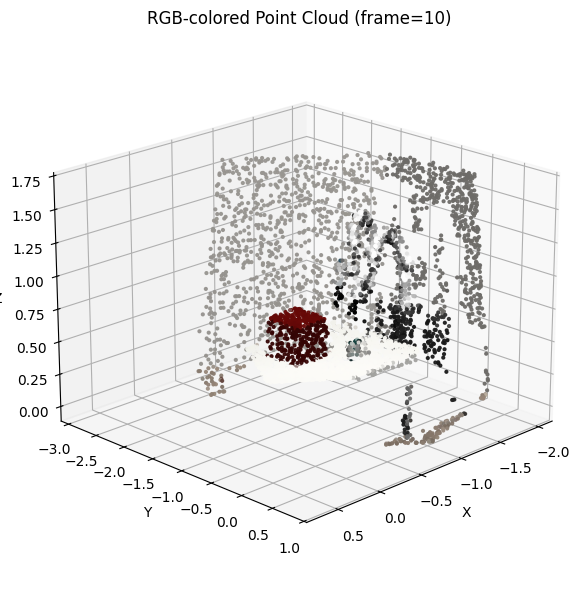

valid colored points: 4096 / 4096


In [12]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

data_path = "/home/benhua/DexSim/dexmimicgen/datasets/generated/two_arm_drawer_cleanup_demo_0_w_pc.hdf5"

with h5py.File(data_path, "r") as f:
    print("顶层 keys:", list(f.keys()))
    print("data attrs:", list(f["data"].attrs.keys()))
    ds = f["data"]
    print("data keys:", list(ds.keys()))
    demo_0 = ds["demo_0"]
    print("demo_0 keys:", list(demo_0.keys()))
    demo_o_obs = demo_0["obs"]
    print("demo_o_obs keys:", list(demo_o_obs.keys()))
    demo_o_obs_thirdview_rgb = demo_o_obs["thirdview_image"]
    demo_0_obs_thirdview_depth = demo_o_obs["thirdview_depth"]
    demo_0_obs_thirdview_pc = demo_o_obs["thirdview_pc"]
    demo_0_obs_thirdview_cam_param = demo_o_obs["thirdview_cam_param"]
    print("demo_o_obs_thirdview shape:", demo_o_obs_thirdview_rgb.shape)
    print("demo_0_obs_thirdview_depth shape:", demo_0_obs_thirdview_depth.shape)
    print("demo_0_obs_thirdview_pc shape:", demo_0_obs_thirdview_pc.shape)
    frame_idx = 10  # 想看第几帧就改这个索引
    rgb = demo_o_obs_thirdview_rgb[frame_idx]          # (84, 84, 3)
    depth = demo_0_obs_thirdview_depth[frame_idx]      # (84, 84)
    pc_world = demo_0_obs_thirdview_pc[frame_idx]            # (2048, 3)
    cam_param = demo_0_obs_thirdview_cam_param[frame_idx]  # (2, 4, 4)

K4 = cam_param[0]           # intrinsic expanded to 4x4
cam_to_world = cam_param[1] # 4x4
world_to_cam = np.linalg.inv(cam_to_world)
H, W = rgb.shape[:2]
# world -> camera
ones = np.ones((pc_world.shape[0], 1), dtype=np.float32)
pc_world_h = np.concatenate([pc_world.astype(np.float32), ones], axis=1)   # (N,4)
pc_cam_h = (world_to_cam @ pc_world_h.T).T                                  # (N,4)
pc_cam = pc_cam_h[:, :3]                                                     # (x,y,z) in camera frame
x, y, z = pc_cam[:, 0], pc_cam[:, 1], pc_cam[:, 2]
# 只保留在相机前方的点
valid_z = z > 1e-6
# camera -> pixel
fx, fy = K4[0, 0], K4[1, 1]
cx, cy = K4[0, 2], K4[1, 2]
u = fx * (x / (z + 1e-8)) + cx   # width direction
v = fy * (y / (z + 1e-8)) + cy   # height direction
u_i = np.round(u).astype(np.int32)
v_i = np.round(v).astype(np.int32)
# 在图像范围内
valid_uv = (u_i >= 0) & (u_i < W) & (v_i >= 0) & (v_i < H)
valid = valid_z & valid_uv
pc_vis = pc_world[valid]
colors = rgb[v_i[valid], u_i[valid]] / 255.0  # matplotlib 需要 [0,1]
# 可视化
fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(pc_vis[:, 0], pc_vis[:, 1], pc_vis[:, 2], c=colors, s=4, alpha=0.9)
ax.set_title(f"RGB-colored Point Cloud (frame={frame_idx})")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
ax.view_init(elev=20, azim=45)
plt.tight_layout()
plt.show()
print(f"valid colored points: {pc_vis.shape[0]} / {pc_world.shape[0]}")

In [8]:
"""提取一个 demo，并保持原始文件结构"""
import os
import h5py

src_path = "/home/benhua/DexSim/dexmimicgen/datasets/generated/two_arm_drawer_cleanup.hdf5"
dst_path = "/home/benhua/DexSim/dexmimicgen/datasets/generated/two_arm_drawer_cleanup_demo_4.hdf5"
demo_name = "demo_4"

def _normalize_item(x):
    if isinstance(x, (bytes, bytearray)):
        return x.decode("utf-8")
    return str(x)

def _filter_demo_dataset_values(values, target_demo):
    # 支持 bytes / str / numpy 标量等，保留与目标 demo 对应的条目
    normalized = [_normalize_item(v) for v in values]
    kept_idx = [i for i, v in enumerate(normalized) if v == target_demo or v == f"data/{target_demo}"]
    if not kept_idx:
        return None
    return values[kept_idx]

if os.path.exists(dst_path):
    os.remove(dst_path)

with h5py.File(src_path, "r") as src, h5py.File(dst_path, "w") as dst:
    # 1) 复制根属性
    for k, v in src.attrs.items():
        dst.attrs[k] = v

    # 2) 先复制除 data 外的所有顶层键，确保整体结构一致
    for key in src.keys():
        if key != "data":
            src.copy(key, dst)

    # 3) 重建 data，并仅复制 demo_10
    src_data = src["data"]
    dst_data = dst.create_group("data")
    for k, v in src_data.attrs.items():
        dst_data.attrs[k] = v

    if demo_name not in src_data:
        raise KeyError(f"{demo_name} not found in source file under /data")

    src.copy(src_data[demo_name], dst_data, name=demo_name)

    # 4) 更新 data 元信息
    dst_data.attrs["total"] = 1
    if "demo_keys" in dst_data.attrs:
        sample = dst_data.attrs["demo_keys"]
        if len(sample) > 0 and isinstance(sample[0], (bytes, bytearray)):
            dst_data.attrs["demo_keys"] = [demo_name.encode("utf-8")]
        else:
            dst_data.attrs["demo_keys"] = [demo_name]

    # 5) 若存在 mask，按 demo 过滤其成员列表
    if "mask" in dst:
        mask_group = dst["mask"]
        for mask_key in list(mask_group.keys()):
            ds = mask_group[mask_key]
            if isinstance(ds, h5py.Dataset):
                filtered = _filter_demo_dataset_values(ds[()], demo_name)
                if filtered is None:
                    del mask_group[mask_key]
                else:
                    del mask_group[mask_key]
                    mask_group.create_dataset(mask_key, data=filtered)

print(f"Done. Saved to: {dst_path}")

Done. Saved to: /home/benhua/DexSim/dexmimicgen/datasets/generated/two_arm_drawer_cleanup_demo_4.hdf5
